# Dataset limpio y listo para el entrenamiento  
## Análisis Exploratorio de Datos (EDA) - Tres Datasets
***Autor:*** Giovanni Cabrera

Actividad orientada a preparar los datos para futuros modelos de Machine Learning.

## Librerías y carga de datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

plt.rcParams["figure.figsize"]=(8,4)

df_salarios = pd.read_csv("data\salaries.csv")
df_attrition = pd.read_csv("data\WA_Fn-UseC_-HR-Employee-Attrition.csv")
df_mfg = pd.read_csv("data\MFG10YearTerminationData.csv")


## Dataset Salaries - Exploración Inicial

In [2]:
df_salarios.head()


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025,SE,FT,Data Product Owner,170000,USD,170000,US,0,US,M
1,2025,SE,FT,Data Product Owner,110000,USD,110000,US,0,US,M
2,2025,SE,FT,Data Product Owner,170000,USD,170000,US,0,US,M
3,2025,SE,FT,Data Product Owner,110000,USD,110000,US,0,US,M
4,2025,SE,FT,Engineer,143000,USD,143000,US,0,US,M


In [3]:
df_salarios.info()


<class 'pandas.DataFrame'>
RangeIndex: 73148 entries, 0 to 73147
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   work_year           73148 non-null  int64
 1   experience_level    73148 non-null  str  
 2   employment_type     73148 non-null  str  
 3   job_title           73148 non-null  str  
 4   salary              73148 non-null  int64
 5   salary_currency     73148 non-null  str  
 6   salary_in_usd       73148 non-null  int64
 7   employee_residence  73148 non-null  str  
 8   remote_ratio        73148 non-null  int64
 9   company_location    73148 non-null  str  
 10  company_size        73148 non-null  str  
dtypes: int64(4), str(7)
memory usage: 6.1 MB


In [4]:
df_salarios.describe(include="all")


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
count,73148.000000,73148,73148,73148,7.314800e+04,73148,73148.000000,73148,73148.000000,73148,73148
unique,NaN,4,4,289,NaN,25,NaN,93,NaN,86,3
top,NaN,SE,FT,Data Scientist,NaN,USD,NaN,US,NaN,US,M
freq,NaN,42926,72808,11443,NaN,69418,NaN,65982,NaN,66035,70536
mean,2023.831192,NaN,NaN,NaN,1.625534e+05,NaN,158013.748619,NaN,21.582955,NaN,NaN
std,0.477551,NaN,NaN,NaN,1.925761e+05,NaN,72501.304728,NaN,41.023051,NaN,NaN
min,2020.000000,NaN,NaN,NaN,1.400000e+04,NaN,15000.000000,NaN,0.000000,NaN,NaN
25%,2024.000000,NaN,NaN,NaN,1.069575e+05,NaN,106890.000000,NaN,0.000000,NaN,NaN
50%,2024.000000,NaN,NaN,NaN,1.480000e+05,NaN,147500.000000,NaN,0.000000,NaN,NaN
75%,2024.000000,NaN,NaN,NaN,2.000000e+05,NaN,199700.000000,NaN,0.000000,NaN,NaN


In [5]:
print("Variables numéricas:")
print(df_salarios.select_dtypes(include=np.number).columns.tolist())
print("Variables categóricas:")
print(df_salarios.select_dtypes(exclude=np.number).columns.tolist())


Variables numéricas:
['work_year', 'salary', 'salary_in_usd', 'remote_ratio']
Variables categóricas:
['experience_level', 'employment_type', 'job_title', 'salary_currency', 'employee_residence', 'company_location', 'company_size']


In [6]:
print(df_salarios.isnull().sum().sort_values(ascending=False).head(20))


work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64


### Detección de Registros Duplicados

Se verificará la existencia de registros duplicados en cada dataset para evaluar la calidad de los datos antes de utilizarlos en modelos de Machine Learning.

In [7]:
duplicados_salarios = df_salarios.duplicated().sum()

print(f"Registros duplicados: {duplicados_salarios}")

Registros duplicados: 39124


In [8]:
porcentaje = (
    duplicados_salarios /
    len(df_salarios)
) * 100

print(f"Porcentaje de duplicados: {porcentaje:.2f}%")

Porcentaje de duplicados: 53.49%


In [9]:
df_salarios[df_salarios.duplicated()].head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
2,2025,SE,FT,Data Product Owner,170000,USD,170000,US,0,US,M
3,2025,SE,FT,Data Product Owner,110000,USD,110000,US,0,US,M
87,2025,EN,FT,Data Analyst,25000,GBP,31645,GB,0,GB,M
124,2025,SE,FT,Data Team Lead,173900,USD,173900,US,0,US,M
125,2025,SE,FT,Data Team Lead,82300,USD,82300,US,0,US,M


## Dataset Employee Attrition - Exploración Inicial

In [10]:
df_attrition.head()


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [11]:
df_attrition.info()


<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [12]:
df_attrition.describe(include="all")


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470,1470,1470.000000,1470,1470.000000,1470.000000,1470,1470.0,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
unique,NaN,2,3,NaN,3,NaN,NaN,6,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,No,Travel_Rarely,NaN,Research & Development,NaN,NaN,Life Sciences,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1233,1043,NaN,961,NaN,NaN,606,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,36.923810,NaN,NaN,802.485714,NaN,9.192517,2.912925,NaN,1.0,1024.865306,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,NaN,NaN,403.509100,NaN,8.106864,1.024165,NaN,0.0,602.024335,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,NaN,NaN,102.000000,NaN,1.000000,1.000000,NaN,1.0,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,NaN,NaN,465.000000,NaN,2.000000,2.000000,NaN,1.0,491.250000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,NaN,NaN,802.000000,NaN,7.000000,3.000000,NaN,1.0,1020.500000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,NaN,NaN,1157.000000,NaN,14.000000,4.000000,NaN,1.0,1555.750000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000


In [13]:
print("Variables numéricas:")
print(df_attrition.select_dtypes(include=np.number).columns.tolist())
print("Variables categóricas:")
print(df_attrition.select_dtypes(exclude=np.number).columns.tolist())


Variables numéricas:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
Variables categóricas:
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


In [14]:
print(df_attrition.isnull().sum().sort_values(ascending=False).head(20))


Age                        0
Attrition                  0
BusinessTravel             0
DailyRate                  0
Department                 0
DistanceFromHome           0
Education                  0
EducationField             0
EmployeeCount              0
EmployeeNumber             0
EnvironmentSatisfaction    0
Gender                     0
HourlyRate                 0
JobInvolvement             0
JobLevel                   0
JobRole                    0
JobSatisfaction            0
MaritalStatus              0
MonthlyIncome              0
MonthlyRate                0
dtype: int64


### Detección de Registros Duplicados

Se verificará la existencia de registros duplicados en cada dataset para evaluar la calidad de los datos antes de utilizarlos en modelos de Machine Learning.

In [15]:
duplicados_attrition = df_attrition.duplicated().sum()

print(f"Registros duplicados: {duplicados_attrition}")

Registros duplicados: 0


In [16]:
df_attrition[df_attrition.duplicated()].head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager


In [17]:
porcentaje = (
    duplicados_attrition /
    len(df_attrition)
) * 100

print(f"Porcentaje de duplicados: {porcentaje:.2f}%")

Porcentaje de duplicados: 0.00%


## Dataset Manufacturing - Exploración Inicial

In [18]:
df_mfg.head()


,EmployeeID,recorddate_key,birthdate_key,orighiredate_key,terminationdate_key,age,length_of_service,city_name,department_name,job_title,store_name,gender_short,gender_full,termreason_desc,termtype_desc,STATUS_YEAR,STATUS,BUSINESS_UNIT
0,1318,12/31/2006 0:00,1/3/1954,8/28/1989,1/1/1900,52,17,Vancouver,Executive,CEO,35,M,Male,Not Applicable,Not Applicable,2006,ACTIVE,HEADOFFICE
1,1318,12/31/2007 0:00,1/3/1954,8/28/1989,1/1/1900,53,18,Vancouver,Executive,CEO,35,M,Male,Not Applicable,Not Applicable,2007,ACTIVE,HEADOFFICE
2,1318,12/31/2008 0:00,1/3/1954,8/28/1989,1/1/1900,54,19,Vancouver,Executive,CEO,35,M,Male,Not Applicable,Not Applicable,2008,ACTIVE,HEADOFFICE
3,1318,12/31/2009 0:00,1/3/1954,8/28/1989,1/1/1900,55,20,Vancouver,Executive,CEO,35,M,Male,Not Applicable,Not Applicable,2009,ACTIVE,HEADOFFICE
4,1318,12/31/2010 0:00,1/3/1954,8/28/1989,1/1/1900,56,21,Vancouver,Executive,CEO,35,M,Male,Not Applicable,Not Applicable,2010,ACTIVE,HEADOFFICE


In [19]:
df_mfg.info()


<class 'pandas.DataFrame'>
RangeIndex: 49653 entries, 0 to 49652
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   EmployeeID           49653 non-null  int64
 1   recorddate_key       49653 non-null  str  
 2   birthdate_key        49653 non-null  str  
 3   orighiredate_key     49653 non-null  str  
 4   terminationdate_key  49653 non-null  str  
 5   age                  49653 non-null  int64
 6   length_of_service    49653 non-null  int64
 7   city_name            49653 non-null  str  
 8   department_name      49653 non-null  str  
 9   job_title            49653 non-null  str  
 10  store_name           49653 non-null  int64
 11  gender_short         49653 non-null  str  
 12  gender_full          49653 non-null  str  
 13  termreason_desc      49653 non-null  str  
 14  termtype_desc        49653 non-null  str  
 15  STATUS_YEAR          49653 non-null  int64
 16  STATUS               49653 non-nu

In [20]:
df_mfg.describe(include="all")


,EmployeeID,recorddate_key,birthdate_key,orighiredate_key,terminationdate_key,age,length_of_service,city_name,department_name,job_title,store_name,gender_short,gender_full,termreason_desc,termtype_desc,STATUS_YEAR,STATUS,BUSINESS_UNIT
count,49653.000000,49653,49653,49653,49653,49653.000000,49653.000000,49653,49653,49653,49653.000000,49653,49653,49653,49653,49653.000000,49653,49653
unique,NaN,130,5342,4415,1055,NaN,NaN,40,21,47,NaN,2,2,4,3,NaN,2,2
top,NaN,12/31/2013 0:00,8/4/1954,8/9/1992,1/1/1900,NaN,NaN,Vancouver,Meats,Meat Cutter,NaN,F,Female,Not Applicable,Not Applicable,NaN,ACTIVE,STORES
freq,NaN,5215,40,50,42450,NaN,NaN,11211,10269,9984,NaN,25898,25898,48168,48168,NaN,48168,49068
mean,4859.495740,NaN,NaN,NaN,NaN,42.077035,10.434596,NaN,NaN,NaN,27.297605,NaN,NaN,NaN,NaN,2010.612612,NaN,NaN
std,1826.571142,NaN,NaN,NaN,NaN,12.427257,6.325286,NaN,NaN,NaN,13.514134,NaN,NaN,NaN,NaN,2.845577,NaN,NaN
min,1318.000000,NaN,NaN,NaN,NaN,19.000000,0.000000,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,2006.000000,NaN,NaN
25%,3360.000000,NaN,NaN,NaN,NaN,31.000000,5.000000,NaN,NaN,NaN,16.000000,NaN,NaN,NaN,NaN,2008.000000,NaN,NaN
50%,5031.000000,NaN,NaN,NaN,NaN,42.000000,10.000000,NaN,NaN,NaN,28.000000,NaN,NaN,NaN,NaN,2011.000000,NaN,NaN
75%,6335.000000,NaN,NaN,NaN,NaN,53.000000,15.000000,NaN,NaN,NaN,42.000000,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN


In [21]:
print("Variables numéricas:")
print(df_mfg.select_dtypes(include=np.number).columns.tolist())
print("Variables categóricas:")
print(df_mfg.select_dtypes(exclude=np.number).columns.tolist())


Variables numéricas:
['EmployeeID', 'age', 'length_of_service', 'store_name', 'STATUS_YEAR']
Variables categóricas:
['recorddate_key', 'birthdate_key', 'orighiredate_key', 'terminationdate_key', 'city_name', 'department_name', 'job_title', 'gender_short', 'gender_full', 'termreason_desc', 'termtype_desc', 'STATUS', 'BUSINESS_UNIT']


In [22]:
print(df_mfg.isnull().sum().sort_values(ascending=False).head(20))


EmployeeID             0
recorddate_key         0
birthdate_key          0
orighiredate_key       0
terminationdate_key    0
age                    0
length_of_service      0
city_name              0
department_name        0
job_title              0
store_name             0
gender_short           0
gender_full            0
termreason_desc        0
termtype_desc          0
STATUS_YEAR            0
STATUS                 0
BUSINESS_UNIT          0
dtype: int64


### Detección de Registros Duplicados

Se verificará la existencia de registros duplicados en cada dataset para evaluar la calidad de los datos antes de utilizarlos en modelos de Machine Learning.

In [23]:
df_mfg[df_mfg.duplicated()].head()

,EmployeeID,recorddate_key,birthdate_key,orighiredate_key,terminationdate_key,age,length_of_service,city_name,department_name,job_title,store_name,gender_short,gender_full,termreason_desc,termtype_desc,STATUS_YEAR,STATUS,BUSINESS_UNIT


In [24]:
duplicados_mfg = df_mfg.duplicated(
    subset=[
        "EmployeeID",
        "STATUS_YEAR"
    ]
).sum()

print(
    "Duplicados EmployeeID-STATUS_YEAR:",
    duplicados_mfg
)

Duplicados EmployeeID-STATUS_YEAR: 5


In [25]:
porcentaje = (
    duplicados_mfg /
    len(df_mfg)
) * 100

print(f"Porcentaje de duplicados: {porcentaje:.2f}%")

Porcentaje de duplicados: 0.01%


## Variables objetivo propuestas
- Salaries: salary_in_usd (continua).
- Attrition: Attrition (binaria).
- Manufacturing: STATUS (binaria).

## Visualizaciones - Salaries

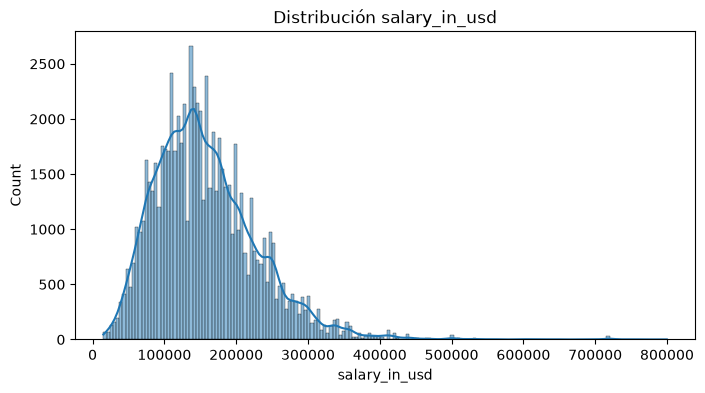

In [26]:
sns.histplot(df_salarios["salary_in_usd"],kde=True)
plt.title("Distribución salary_in_usd")
plt.show()


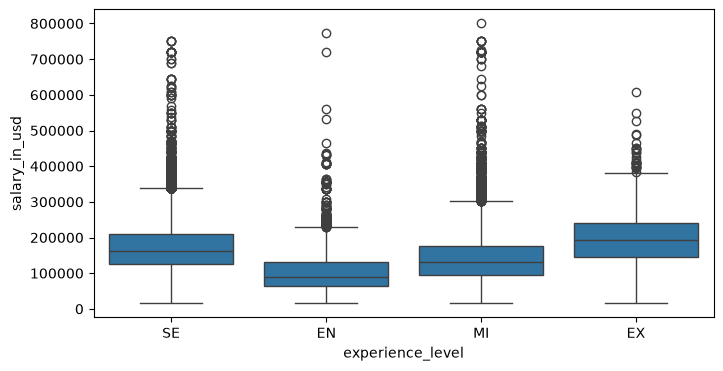

In [27]:
sns.boxplot(data=df_salarios,x="experience_level",y="salary_in_usd")
plt.show()


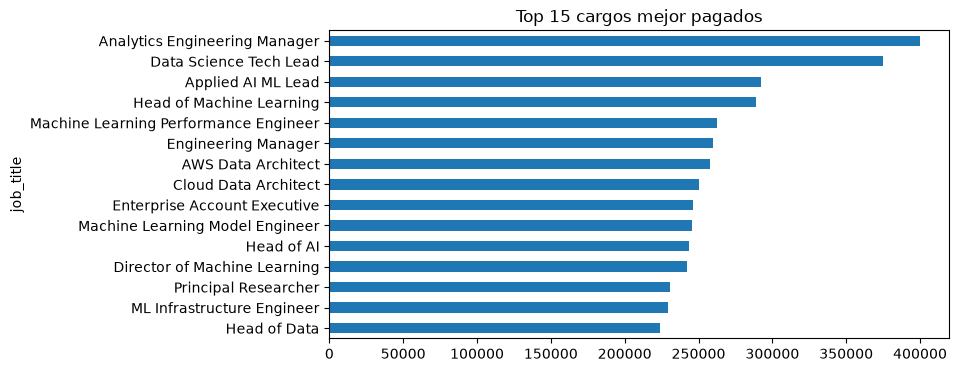

In [28]:
top=df_salarios.groupby("job_title")["salary_in_usd"].mean().sort_values(ascending=False).head(15)
top.sort_values().plot(kind="barh")
plt.title("Top 15 cargos mejor pagados")
plt.show()


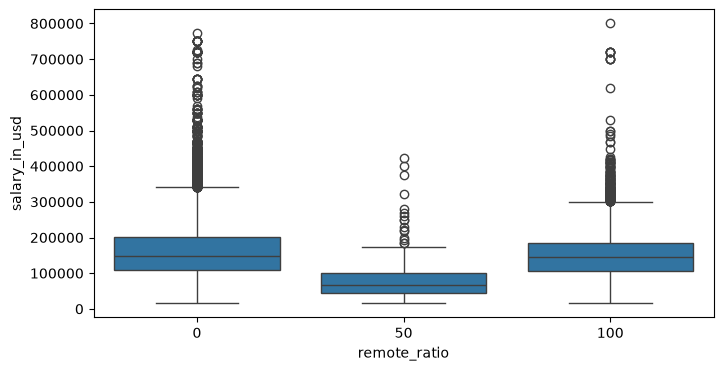

In [29]:
sns.boxplot(data=df_salarios,x="remote_ratio",y="salary_in_usd")
plt.show()


## Visualizaciones - Employee Attrition

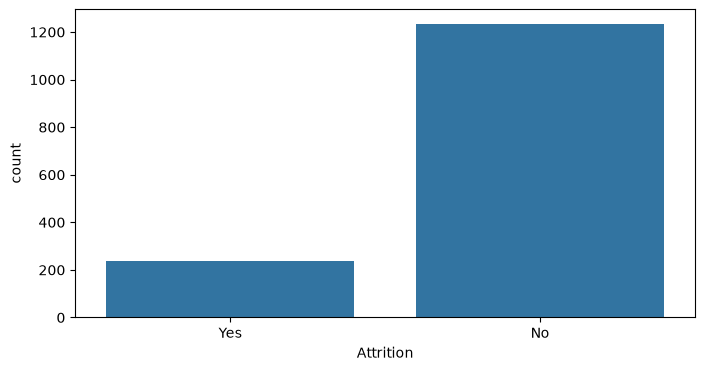

In [30]:
sns.countplot(data=df_attrition,x="Attrition")
plt.show()


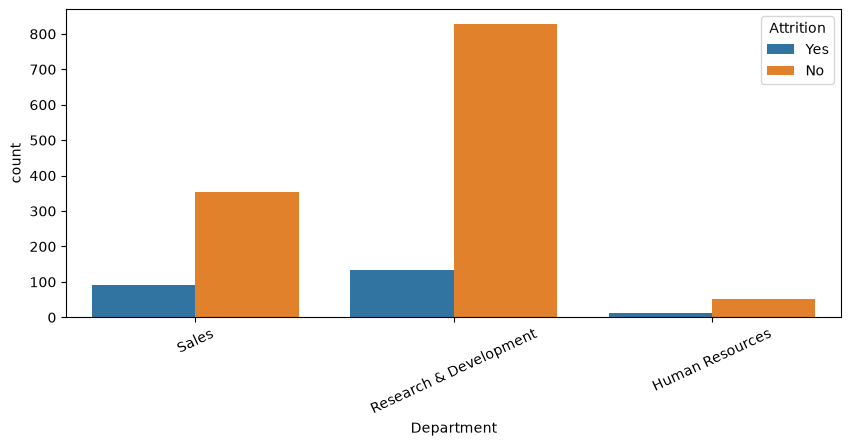

In [31]:
plt.figure(figsize=(10,4))
sns.countplot(data=df_attrition,x="Department",hue="Attrition")
plt.xticks(rotation=25)
plt.show()


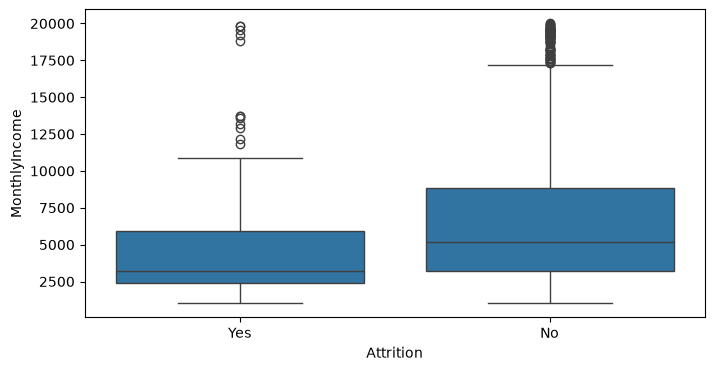

In [32]:
sns.boxplot(data=df_attrition,x="Attrition",y="MonthlyIncome")
plt.show()


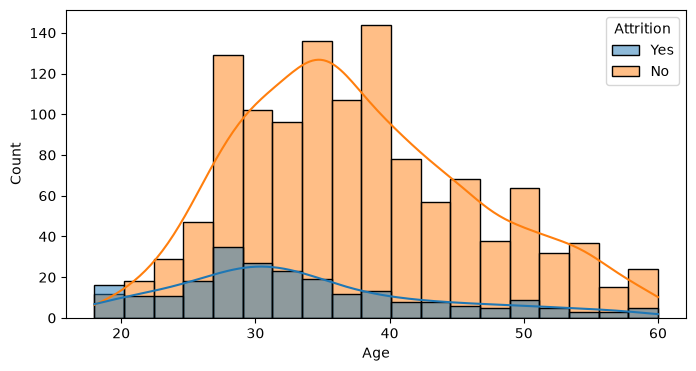

In [33]:
sns.histplot(data=df_attrition,x="Age",hue="Attrition",kde=True)
plt.show()


## Visualizaciones - Manufacturing

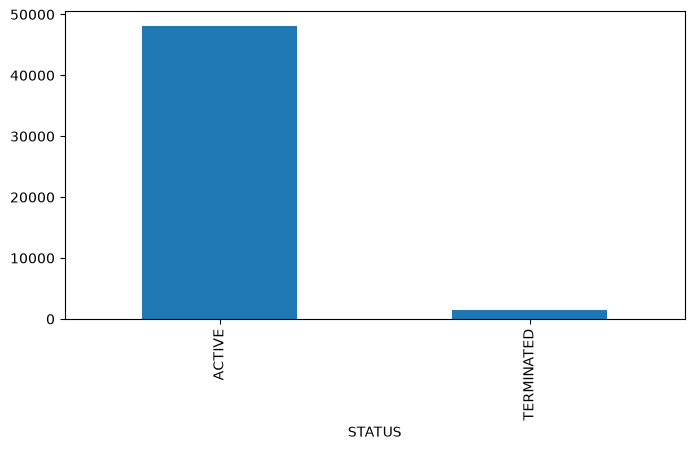

In [34]:
df_mfg["STATUS"].value_counts().plot(kind="bar")
plt.show()


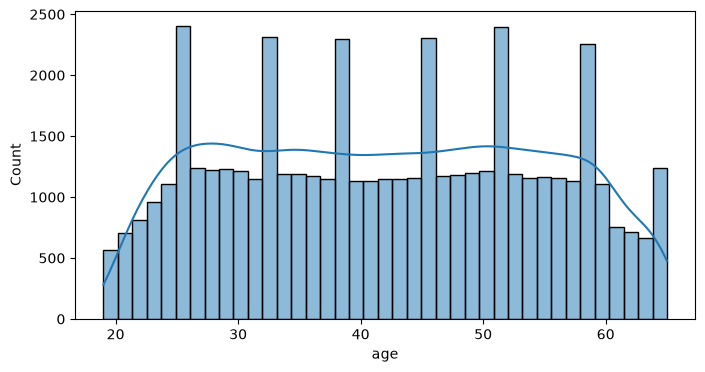

In [35]:
sns.histplot(df_mfg["age"],kde=True)
plt.show()


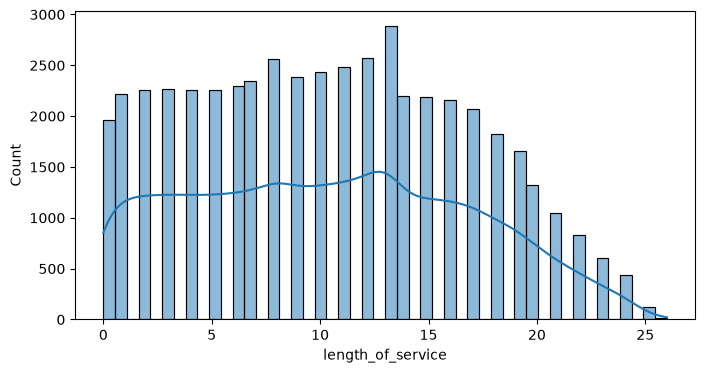

In [36]:
sns.histplot(df_mfg["length_of_service"],kde=True)
plt.show()


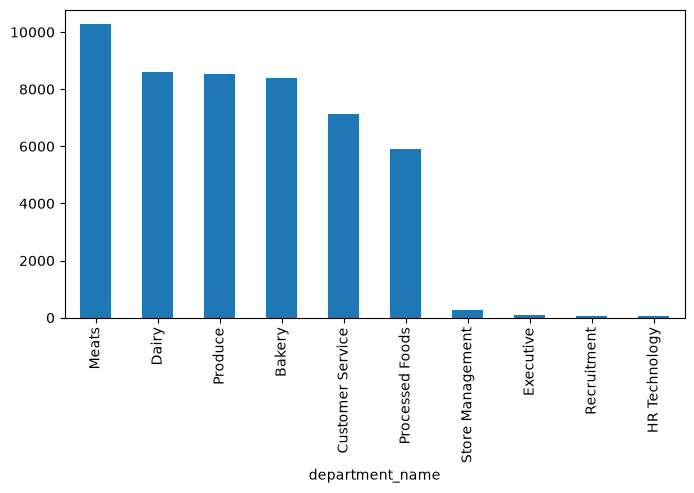

In [37]:
df_mfg["department_name"].value_counts().head(10).plot(kind="bar")
plt.show()


## Detección de Outliers

In [38]:
def detectar_outliers(df,col):
 q1=df[col].quantile(0.25)
 q3=df[col].quantile(0.75)
 iqr=q3-q1
 return len(df[(df[col]<(q1-1.5*iqr))|(df[col]>(q3+1.5*iqr))])


In [39]:
for c in ["salary_in_usd"]:
 print(c, detectar_outliers(df_salarios,c))


salary_in_usd 1369


In [40]:
for c in ["MonthlyIncome","TotalWorkingYears"]:
 print(c, detectar_outliers(df_attrition,c))


MonthlyIncome 114
TotalWorkingYears 63


In [41]:
for c in ["age","length_of_service"]:
 print(c, detectar_outliers(df_mfg,c))


age 0
length_of_service 0


## Correlaciones

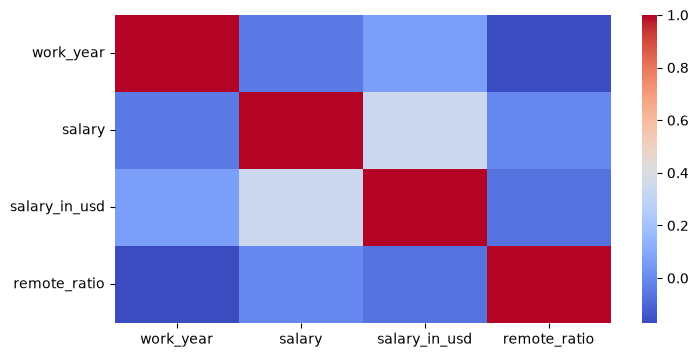

In [42]:
sns.heatmap(df_salarios.select_dtypes(include=np.number).corr(),cmap="coolwarm")
plt.show()


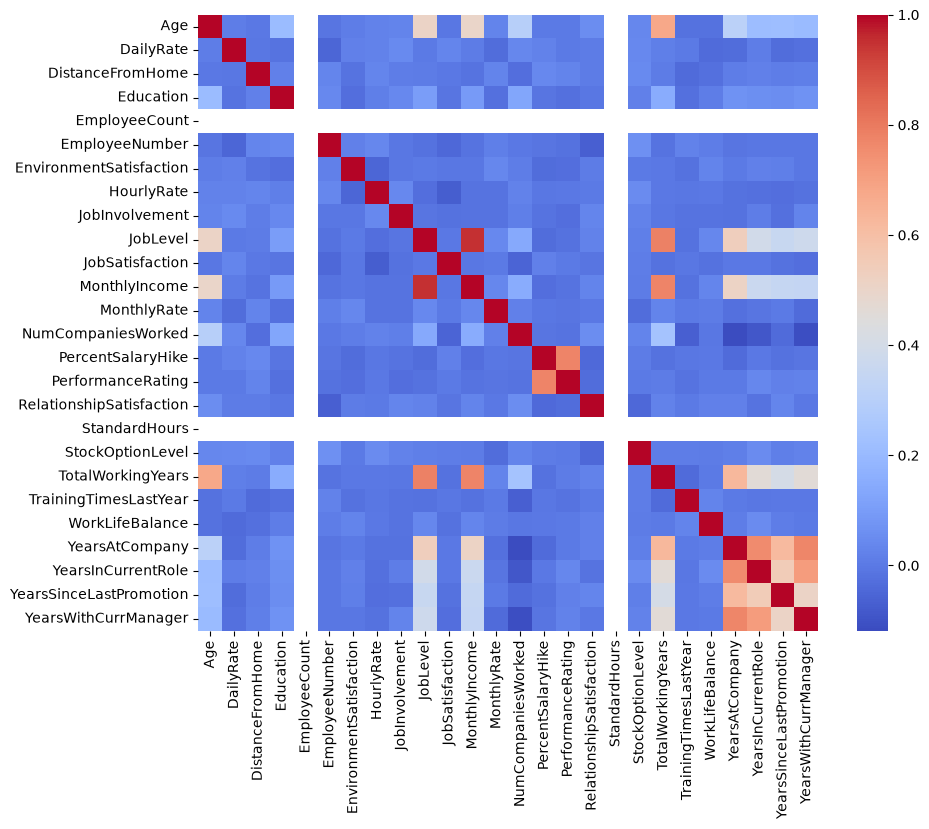

In [43]:
plt.figure(figsize=(10,8))
sns.heatmap(df_attrition.select_dtypes(include=np.number).corr(),cmap="coolwarm")
plt.show()


## Estadísticas descriptivas y estrategia de imputación

In [44]:
for nombre,df in [("Salarios",df_salarios),("Attrition",df_attrition),("MFG",df_mfg)]:
 print("\n",nombre)
 nums=df.select_dtypes(include=np.number).columns
 for c in list(nums)[:10]:
  print(c,"Media",df[c].mean(),"Mediana",df[c].median(),"Moda",df[c].mode()[0])



 Salarios
work_year Media 2023.8311915568436 Mediana 2024.0 Moda 2024
salary Media 162553.43537759065 Mediana 148000.0 Moda 160000
salary_in_usd Media 158013.7486192377 Mediana 147500.0 Moda 160000
remote_ratio Media 21.5829551047192 Mediana 0.0 Moda 0

 Attrition
Age Media 36.923809523809524 Mediana 36.0 Moda 35
DailyRate Media 802.4857142857143 Mediana 802.0 Moda 691
DistanceFromHome Media 9.19251700680272 Mediana 7.0 Moda 2
Education Media 2.912925170068027 Mediana 3.0 Moda 3
EmployeeCount Media 1.0 Mediana 1.0 Moda 1
EmployeeNumber Media 1024.865306122449 Mediana 1020.5 Moda 1
EnvironmentSatisfaction Media 2.721768707482993 Mediana 3.0 Moda 3
HourlyRate Media 65.89115646258503 Mediana 66.0 Moda 66
JobInvolvement Media 2.7299319727891156 Mediana 3.0 Moda 3
JobLevel Media 2.0639455782312925 Mediana 2.0 Moda 1

 MFG
EmployeeID Media 4859.495740438644 Mediana 5031.0 Moda 1318
age Media 42.077034620264634 Mediana 42.0 Moda 27
length_of_service Media 10.434596096912573 Mediana 10.0 Moda

## Hallazgos Técnicos
1. El dataset Salaries está orientado a problemas de regresión salarial.
2. Se observa duplicidad del 53.49% en el dataset Salaries.
3. Se observa duplicidad del 0.01% en el dataset Manufacturing cuando se analiza al cliente por año
4. No se observa duplicidad en el dataset restante: Attrition
5. salary_in_usd presenta dispersión elevada y valores atípicos.
6. Los niveles Senior concentran los salarios más altos.
7. La modalidad remota muestra diferencias salariales.
8. Attrition es adecuado para clasificación binaria.
9. MonthlyIncome y OverTime parecen variables relevantes para rotación.
10. Research & Development concentra gran cantidad de empleados.
11. Manufacturing posee estructura longitudinal por empleado.
12. length_of_service y age son variables importantes para permanencia.
13. Existen outliers que deberán evaluarse antes del modelado.
14. Los datasets contienen variables numéricas y categóricas suficientes para ML.
15. Los tres datasets son aptos para ejercicios futuros de clasificación y regresión.